# Peak District SegFormer — End-to-End (Zero-Shot + Quick Fine-Tune)
Colab-friendly pipeline with:
- Auto dataset discovery
- Zero-shot metrics + **landscape** triptychs (top-3 legends)
- Quick fine-tune (2 epochs) + checkpoint
- Fine-tuned metrics + matching triptychs
- Optional Drive export


In [ ]:
%%capture
!pip -q install -U transformers accelerate scikit-learn

In [ ]:
# === Peak District SegFormer — End-to-End (with auto-unzip) ===
# What this does:
# 1) Looks for /content/**/python_format; if missing, finds a dataset ZIP in /content and unzips it.
# 2) Loads label names (lc_label_names.json) and optional ADE->Peak mapping CSV.
# 3) Zero-shot metrics + landscape triptychs (top-3 legends).
# 4) Quick fine-tune (2 epochs, 25% subset) + checkpoint.
# 5) Fine-tuned metrics + matching triptychs.
# 6) Optionally copies artifacts to Drive if mounted.

# ---- Installs (quiet) ----
try:
    import transformers, sklearn  # noqa: F401
except Exception:
    import sys, subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-U", "transformers", "accelerate", "scikit-learn"])

# ---- Imports ----
import os, json, shutil, random, zipfile
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor, SegformerConfig

# ---- Repro ----
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

# ---- Optional Drive mount (safe if not in Colab) ----
try:
    from google.colab import drive  # type: ignore
    if not Path("/content/drive").exists():
        drive.mount('/content/drive', force_remount=False)
    IN_COLAB = True
except Exception:
    IN_COLAB = False

RUNS_DRIVE = Path("/content/drive/MyDrive/segformer_runs") if IN_COLAB else None
if RUNS_DRIVE: RUNS_DRIVE.mkdir(parents=True, exist_ok=True)

# ---- Helper: find or unzip dataset to get python_format/ ----
def find_python_format_root() -> Path:
    # Prefer anything under /content first
    for base in [Path("/content")]:
        if base.exists():
            for r, d, f in os.walk(base):
                if "python_format" in d:
                    return Path(r) / "python_format"
    return None

def try_unzip_dataset() -> Path:
    # Look for a likely ZIP under /content
    zips = sorted(
        [p for p in Path("/content").glob("*.zip")],
        key=lambda p: p.stat().st_mtime,
        reverse=True
    )
    if not zips:
        raise FileNotFoundError(
            "No dataset found. Upload your dataset ZIP to /content, then re-run.\n"
            "Expected the ZIP to contain a folder with 'python_format/'."
        )
    # Pick most recent ZIP
    z = zips[0]
    print(f"Unzipping: {z}")
    with zipfile.ZipFile(z, 'r') as zf:
        zf.extractall("/content")
    # Search again
    pf = find_python_format_root()
    if pf is None:
        raise FileNotFoundError(
            f"Unzipped {z.name}, but couldn't find 'python_format/' inside. "
            "Open the ZIP to ensure it contains that folder."
        )
    return pf

PYTHON_FORMAT = find_python_format_root()
if PYTHON_FORMAT is None:
    PYTHON_FORMAT = try_unzip_dataset()

print("Found python_format at:", PYTHON_FORMAT)
IMG_DIR  = PYTHON_FORMAT / "images_python_all"
MASK_DIR = PYTHON_FORMAT / "masks_python_all"
assert IMG_DIR.is_dir() and MASK_DIR.is_dir(), "images_python_all/masks_python_all missing."

# ---- Label map (Peak) ----
def find_file_in_dirs(fname: str, extra_dirs=None):
    paths = [
        Path("/content")/fname,
        PYTHON_FORMAT.parent / fname,
        Path("/content/drive/MyDrive")/fname,
    ]
    if extra_dirs:
        paths = extra_dirs + paths
    for p in paths:
        if p.exists():
            return p
    return None

label_json = find_file_in_dirs("lc_label_names.json")
if label_json is None:
    raise FileNotFoundError(
        "lc_label_names.json not found. Upload it to /content or next to the dataset (same level as python_format/)."
    )
id2name_peak = {int(k): v for k, v in json.loads(label_json.read_text()).items()}
NUM_CLASSES = len(id2name_peak)
print("Classes:", NUM_CLASSES)

Device: cpu
Unzipping: /content/peak_district_data.zip
Found python_format at: /content/peak_district_data1/python_format
Classes: 45


In [ ]:
# === 1) Setup: imports, device, models, dataset discovery (fresh-session safe) ===
import os, json, shutil, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import torch, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix
from transformers import SegformerForSemanticSegmentation, SegformerImageProcessor, SegformerConfig

# Repro
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Device:", DEVICE)

# -- Drive (optional) --
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
    if not Path("/content/drive").exists():
        drive.mount('/content/drive', force_remount=False)
except Exception:
    IN_COLAB = False
RUNS_DRIVE = Path("/content/drive/MyDrive/segformer_runs") if IN_COLAB else None
if RUNS_DRIVE: RUNS_DRIVE.mkdir(parents=True, exist_ok=True)

# -- Dataset discovery --
def find_python_format_root():
    prefer = Path("/content/peak_district_data")
    if prefer.exists():
        for r, d, f in os.walk(prefer):
            if "python_format" in d: return Path(r) / "python_format"
    for r, d, f in os.walk("/content"):
        if "python_format" in d: return Path(r) / "python_format"
    raise FileNotFoundError("Couldn't find 'python_format'. Upload/unzip your ZIP under /content then re-run.")

PYTHON_FORMAT = find_python_format_root()
IMG_DIR  = PYTHON_FORMAT / "images_python_all"
MASK_DIR = PYTHON_FORMAT / "masks_python_all"
assert IMG_DIR.is_dir() and MASK_DIR.is_dir(), "images_python_all/masks_python_all missing."

# -- Label map (Peak) --
label_json = None
for cand in [Path("/content/lc_label_names.json"),
             PYTHON_FORMAT.parent / "lc_label_names.json",
             Path("/content/drive/MyDrive/lc_label_names.json")]:
    if cand.exists(): label_json = cand; break
assert label_json is not None, "lc_label_names.json not found. Upload it to /content or alongside the dataset."
id2name_peak = {int(k): v for k, v in json.loads(label_json.read_text()).items()}
NUM_CLASSES = len(id2name_peak)
print("Classes:", NUM_CLASSES)

# -- Optional ADE->Peak mapping for zero-shot remap --
ade_to_peak = None
for cand in [Path("/content/ade20k_to_peakdistrict.csv"),
             PYTHON_FORMAT.parent / "ade20k_to_peakdistrict.csv",
             Path("/content/drive/MyDrive/ade20k_to_peakdistrict.csv")]:
    if cand.exists():
        dfmap = pd.read_csv(cand)
        if {"ade_id","peak_id"}.issubset(dfmap.columns):
            ade_to_peak = {int(r.ade_id): int(r.peak_id) for _, r in dfmap.iterrows()}
            print("Loaded ADE->Peak mapping:", cand)
        break

# -- Semantic colors (stable, name-based) --
def color_from_name(name: str) -> tuple:
    n = name.lower()
    if "water" in n:                                    return ( 54,144,192)
    if "wet" in n or "bog" in n or "peat" in n:         return ( 66,179,213)
    if "forest" in n or "wood" in n or "tree" in n:     return ( 34,139, 34)
    if "scrub" in n or "shrub" in n:                    return (112,128, 40)
    if "grass" in n or "pasture" in n or "meadow" in n: return (173,220, 73)
    if "heather" in n or "moor" in n:                   return (171, 78,190)
    if "crop" in n or "arable" in n or "field" in n:    return (240,221, 70)
    if "road" in n or "track" in n:                     return (128,128,128)
    if "building" in n or "urban" in n or "settlement" in n: return (230, 85, 13)
    if "rock" in n or "bare" in n or "scree" in n:      return (160,160,160)
    if "sand" in n or "beach" in n:                     return (237,201,175)
    return (100,149,237)

CLASS_COLORS = {}
def rgb_for_id(cid: int) -> tuple:
    if cid not in CLASS_COLORS:
        CLASS_COLORS[cid] = color_from_name(id2name_peak.get(int(cid), str(cid)))
    return CLASS_COLORS[cid]

def mask_to_rgb(mask: np.ndarray) -> np.ndarray:
    rgb = np.zeros((*mask.shape, 3), dtype=np.uint8)
    for cid in np.unique(mask):
        rgb[mask == cid] = rgb_for_id(int(cid))
    return rgb

def summarize(mask: np.ndarray, top_k=3):
    vals, counts = np.unique(mask, return_counts=True)
    order = np.argsort(-counts)
    vals, counts = vals[order][:top_k], counts[order][:top_k]
    total = mask.size
    items = []
    for cid, cnt in zip(vals, counts):
        name = id2name_peak.get(int(cid), str(cid))
        pct  = 100.0 * (cnt / total)
        color = np.array(rgb_for_id(int(cid))) / 255.0
        items.append((int(cid), name, pct, color))
    return items

# -- Simple loaders --
def load_img_chw_float01(path: Path):
    arr = np.load(str(path)).astype(np.float32)
    if arr.max() > 1.0: arr = arr / 255.0
    return arr  # (C,H,W)

def load_mask_hw(path: Path):
    return np.load(str(path)).astype(np.int64)  # (H,W)

# -- Zero-shot model (ADE) --
ZS_MODEL_ID = "nvidia/segformer-b0-finetuned-ade-512-512"
processor = SegformerImageProcessor.from_pretrained(ZS_MODEL_ID)
zs_model  = SegformerForSemanticSegmentation.from_pretrained(ZS_MODEL_ID).to(DEVICE).eval()

@torch.no_grad()
def predict_logits_zero_shot(img_chw):
    arr = np.transpose(img_chw, (1,2,0))
    if arr.shape[2] == 1: arr = np.repeat(arr, 3, axis=2)
    arr = (np.clip(arr, 0, 1) * 255).astype(np.uint8)
    inputs = processor(images=arr, return_tensors="pt").to(DEVICE)
    return zs_model(**inputs).logits

def remap_ade_to_peak(mask_ade: np.ndarray) -> np.ndarray:
    if ade_to_peak is None: return mask_ade
    out = mask_ade.copy()
    for v in np.unique(mask_ade):
        out[mask_ade == v] = ade_to_peak.get(int(v), 0)
    return out

# -- Fine-tune model scaffold (Peak label space) --
BASE_ID = "nvidia/segformer-b0-finetuned-ade-512-512"
ft_config = SegformerConfig.from_pretrained(BASE_ID, num_labels=NUM_CLASSES, ignore_mismatched_sizes=True)
ft_model  = SegformerForSemanticSegmentation.from_pretrained(BASE_ID, config=ft_config, ignore_mismatched_sizes=True).to(DEVICE).eval()

print("Setup complete.")


Device: cpu
Classes: 45


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

/usr/local/lib/python3.11/dist-packages/transformers/image_processing_base.py:412: UserWarning: The following named arguments are not valid for `SegformerImageProcessor.__init__` and were ignored: 'feature_extractor_type', 'reduce_labels'
  image_processor = cls(**image_processor_dict)


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/15.0M [00:00<?, ?B/s]

Some weights of SegformerForSemanticSegmentation were not initialized from the model checkpoint at nvidia/segformer-b0-finetuned-ade-512-512 and are newly initialized because the shapes did not match:
- decode_head.classifier.bias: found shape torch.Size([150]) in the checkpoint and torch.Size([45]) in the model instantiated
- decode_head.classifier.weight: found shape torch.Size([150, 256, 1, 1]) in the checkpoint and torch.Size([45, 256, 1, 1]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Setup complete.


In [ ]:
# === 2) Split discovery + dataset/dataloader (10% val if no 'val' in JSON) ===
split_candidates = list(PYTHON_FORMAT.glob("train_test_split_80tiles*.json")) or list(Path("/content").glob("train_test_split_80tiles*.json"))
assert split_candidates, "No split JSON found."
SPLIT_JSON = split_candidates[0]
print("Using split:", SPLIT_JSON)

with open(SPLIT_JSON) as f:
    split_info = json.load(f)

def to_img_name(n): return n if n.endswith(".npy") else f"{n}.npy"
def mask_name(n):  return n.replace(".npy", "_lc_2022_detailed_mask.npy")

imgs = set(os.listdir(IMG_DIR))
masks= set(os.listdir(MASK_DIR))

def match_list(names):
    ok, miss_img, miss_msk = [], [], []
    for raw in names:
        n = to_img_name(raw); m = mask_name(n)
        if n not in imgs: miss_img.append(n); continue
        if m not in masks: miss_msk.append(m); continue
        ok.append(n)
    return ok, miss_img, miss_msk

train_raw = split_info.get("train", [])
test_raw  = split_info.get("test",  [])
val_raw   = split_info.get("val",   [])

train_files, mi_ti, mm_tm = match_list(train_raw)
test_files,  mi_te, mm_te = match_list(test_raw)
val_files,   mi_v , mm_vm = match_list(val_raw)

if not val_files:
    random.seed(SEED)
    random.shuffle(train_files)
    k = max(1, int(0.10 * len(train_files)))
    val_files = train_files[:k]
    train_files = train_files[k:]

print(f"Counts → Train={len(train_files)}, Val={len(val_files)}, Test={len(test_files)}")

class PeakDataset(Dataset):
    def __init__(self, names): self.names = names
    def __len__(self): return len(self.names)
    def __getitem__(self, i):
        n = self.names[i]
        img = load_img_chw_float01(IMG_DIR / n)
        msk = load_mask_hw(MASK_DIR / mask_name(n))
        return torch.from_numpy(img), torch.from_numpy(msk).long(), n

BATCH_TRAIN, BATCH_EVAL = 2, 1
train_ds = PeakDataset(train_files)
val_ds   = PeakDataset(val_files)
test_ds  = PeakDataset(test_files)

train_loader = DataLoader(train_ds, batch_size=BATCH_TRAIN, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_EVAL,  shuffle=False, num_workers=2, pin_memory=True)

sel3 = sorted(test_files)[:3]
Path("/content/selection.json").write_text(json.dumps(sel3, indent=2))
print("sel3:", sel3)


Using split: /content/peak_district_data1/python_format/train_test_split_80tiles_2023-03-22-2131.json
Counts → Train=647, Val=71, Test=308
sel3: ['SE0407_patch061.npy', 'SE0407_patch077.npy', 'SE0407_patch177.npy']


Zero-shot PixelAcc=1.39%, mIoU=0.07%


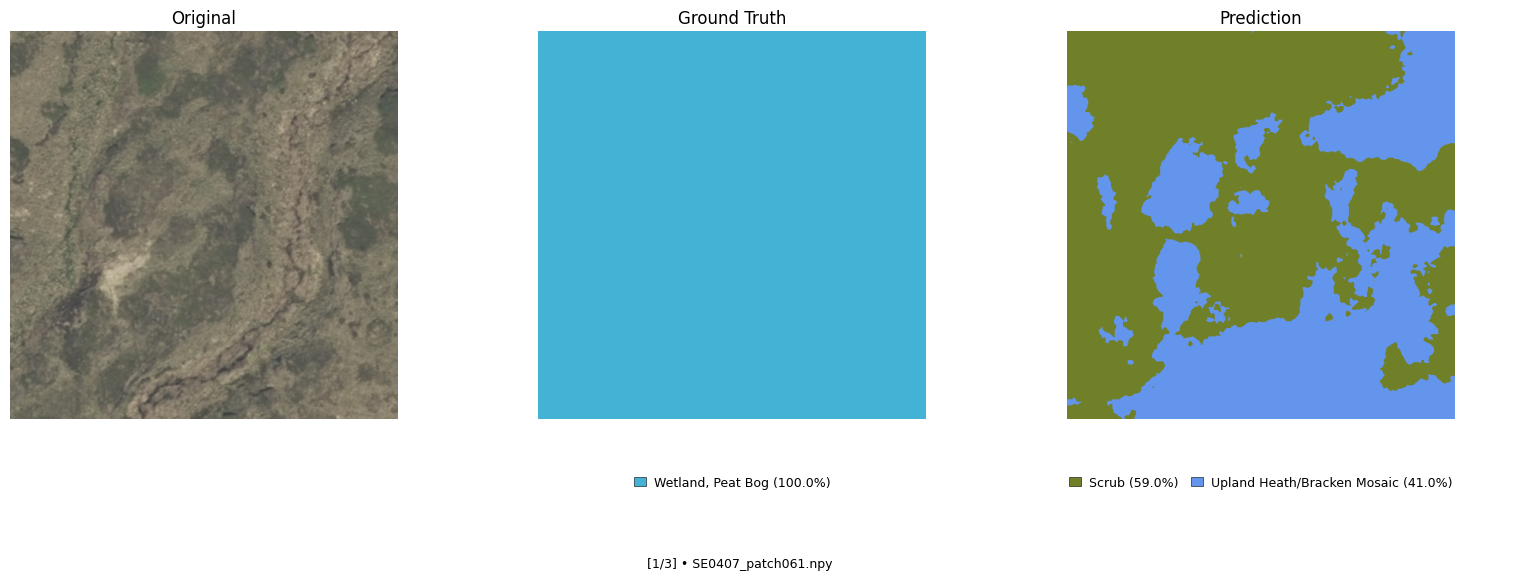

Saved: /content/predictions_zero_shot/SE0407_patch061_zero_shot_landscape.png


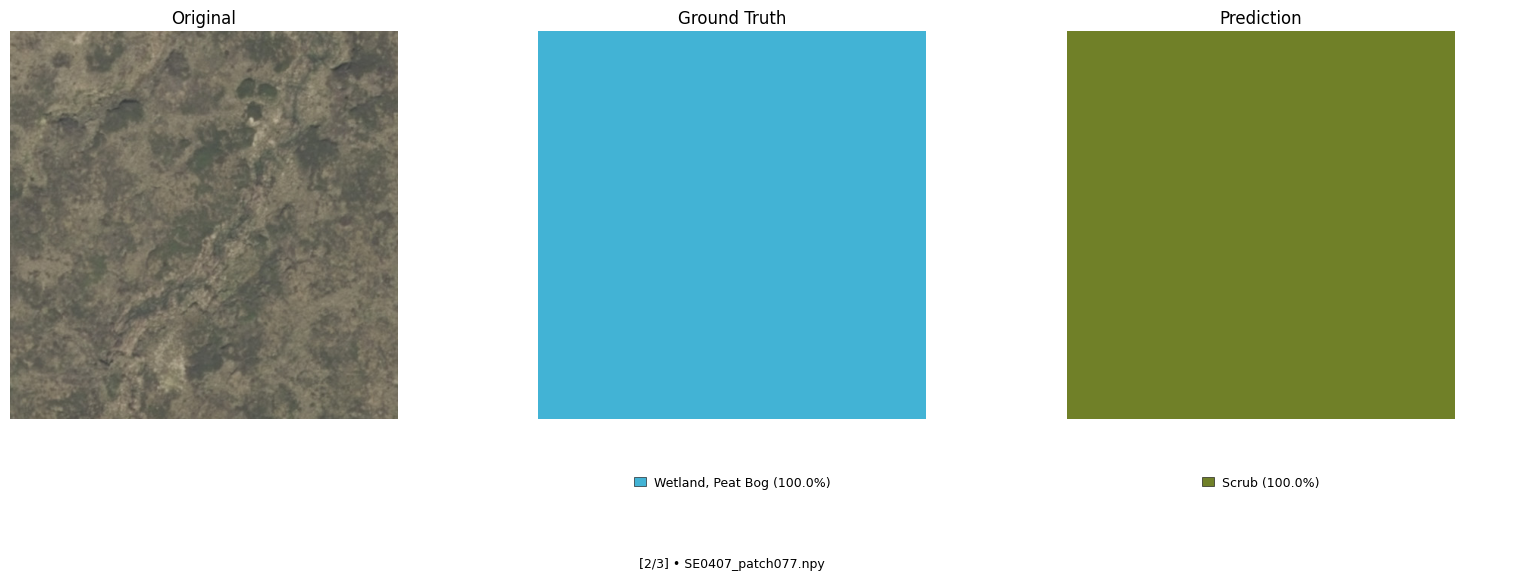

Saved: /content/predictions_zero_shot/SE0407_patch077_zero_shot_landscape.png


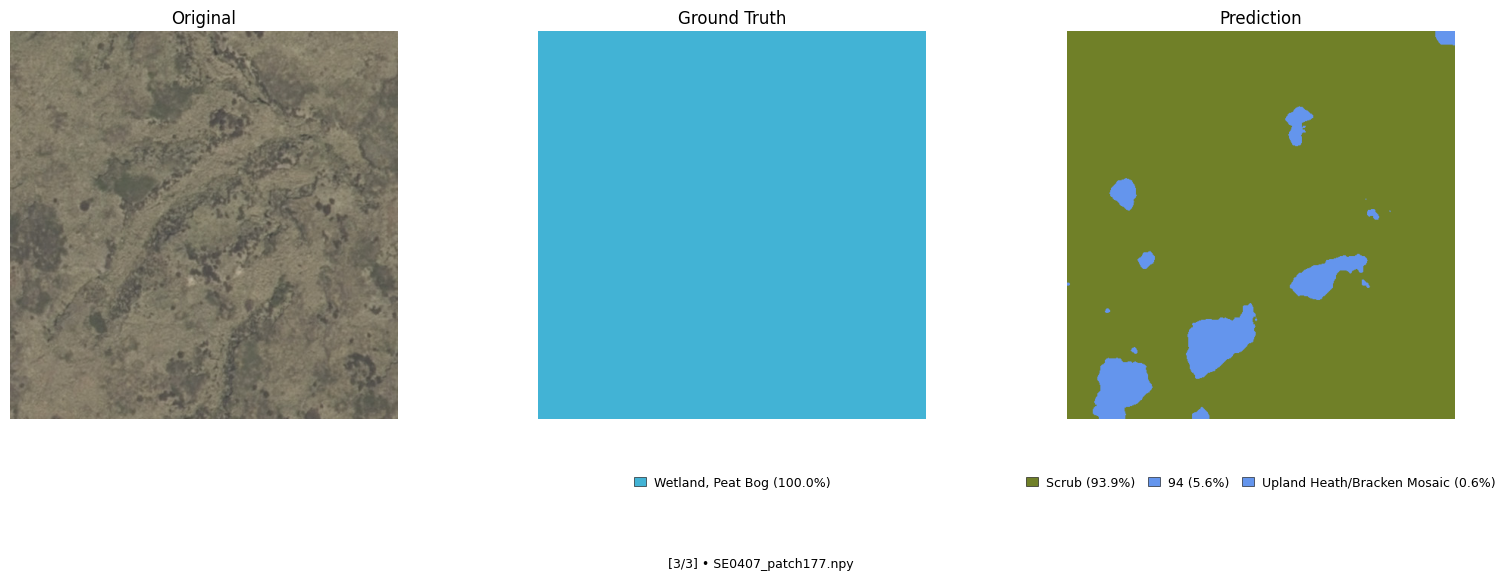

Saved: /content/predictions_zero_shot/SE0407_patch177_zero_shot_landscape.png
Copied zero-shot artifacts to Drive.


In [ ]:
# === 3) ZERO-SHOT: metrics + landscape triptychs with top-3 legends ===
ZS_DIR = Path("/content/predictions_zero_shot"); ZS_DIR.mkdir(parents=True, exist_ok=True)

all_true, all_pred = [], []
with torch.no_grad():
    for img_t, mask_t, _ in test_loader:
        img = img_t[0].cpu().numpy(); gt = mask_t[0].cpu().numpy()
        logits = predict_logits_zero_shot(img)
        up = F.interpolate(logits, size=gt.shape[-2:], mode="bilinear", align_corners=False)
        pred_ade = up.argmax(dim=1)[0].detach().cpu().numpy().astype(np.int64)
        pred = remap_ade_to_peak(pred_ade)
        all_true.append(gt.ravel()); all_pred.append(pred.ravel())

if all_true:
    y_true = np.concatenate(all_true); y_pred = np.concatenate(all_pred)
    labels = np.arange(max(int(y_pred.max()), 0) + 1)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    pix_acc = float(cm.trace() / cm.sum()) if cm.sum() > 0 else 0.0
    inter = np.diag(cm).astype(np.float64)
    union = cm.sum(axis=1) + cm.sum(axis=0) - inter
    iou = inter / np.maximum(union, 1)
    miou = float(np.nanmean(iou))
else:
    pix_acc, miou = 0.0, 0.0

print(f"Zero-shot PixelAcc={pix_acc*100:.2f}%, mIoU={miou*100:.2f}%")
pd.DataFrame([{"pixel_acc": pix_acc, "miou": miou}]).to_csv("/content/segformer_b0_zero_shot_metrics.csv", index=False)

def legend_in_axis(ax, items, ncol=3):
    ax.axis("off")
    handles = [mpatches.Patch(facecolor=c, edgecolor='black', linewidth=0.4) for (_,_,_,c) in items]
    labels  = [f"{n} ({p:.1f}%)" for (_,n,p,_) in items]
    if not labels:
        labels, handles = ["(no classes)"], [mpatches.Patch(facecolor=(0,0,0,0))]
    ax.legend(handles, labels, loc="center", ncol=min(ncol, max(1, len(labels))),
              frameon=False, fontsize=9, handlelength=1, handletextpad=0.6, columnspacing=1.0)

for rank, name in enumerate(sel3, start=1):
    img = load_img_chw_float01(IMG_DIR / name)
    gt  = load_mask_hw(MASK_DIR / name.replace(".npy","_lc_2022_detailed_mask.npy"))
    logits = predict_logits_zero_shot(img)
    up = F.interpolate(logits, size=gt.shape[-2:], mode="bilinear", align_corners=False)
    pred_ade = up.argmax(dim=1)[0].detach().cpu().numpy().astype(np.int64)
    pred = remap_ade_to_peak(pred_ade)

    gt_rgb, pr_rgb = mask_to_rgb(gt), mask_to_rgb(pred)
    gt_items, pr_items = summarize(gt, 3), summarize(pred, 3)

    fig = plt.figure(figsize=(16,6))
    gs  = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[4,1])
    ax_o = fig.add_subplot(gs[0,0]); ax_g = fig.add_subplot(gs[0,1]); ax_p = fig.add_subplot(gs[0,2])
    ax_gl= fig.add_subplot(gs[1,1]); ax_pl= fig.add_subplot(gs[1,2])

    orig = (np.transpose(img,(1,2,0))*255).astype(np.uint8)
    if orig.shape[2]==1: orig=np.repeat(orig,3,axis=2)
    ax_o.imshow(orig); ax_o.set_title("Original"); ax_o.axis("off")
    ax_g.imshow(gt_rgb); ax_g.set_title("Ground Truth"); ax_g.axis("off")
    ax_p.imshow(pr_rgb); ax_p.set_title("Prediction"); ax_p.axis("off")
    legend_in_axis(ax_gl, gt_items); legend_in_axis(ax_pl, pr_items)
    fig.text(0.5, 0.02, f"[{rank}/3] • {name}", ha="center", va="bottom", fontsize=9)

    outp = ZS_DIR / f"{Path(name).stem}_zero_shot_landscape.png"
    plt.tight_layout(rect=[0,0.06,1,0.98]); plt.savefig(outp, dpi=140, bbox_inches="tight"); plt.show()
    print("Saved:", outp)

if RUNS_DRIVE:
    (RUNS_DRIVE/"zero_shot").mkdir(parents=True, exist_ok=True)
    shutil.copy2("/content/segformer_b0_zero_shot_metrics.csv", RUNS_DRIVE/"zero_shot/segformer_b0_zero_shot_metrics.csv")
    for p in ZS_DIR.glob("*.png"): shutil.copy2(p, RUNS_DRIVE/"zero_shot"/p.name)
    print("Copied zero-shot artifacts to Drive.")


In [ ]:
# === 4) Quick fine-tune (2 epochs, subset) + checkpoint ===
ft_model.train()
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=3e-4, weight_decay=1e-4)
scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
EPOCHS = 2; ACCUM = 4; SAMPLE_FRACTION = 0.25

def fast_subset_idx(n_total, fraction, seed=SEED):
    if fraction >= 1.0: return list(range(n_total))
    n = max(1, int(n_total*fraction))
    rng = np.random.default_rng(seed)
    return rng.choice(n_total, size=n, replace=False).tolist()

def quick_eval(model, loader, max_items=64):
    model.eval(); ys, ps = [], []
    with torch.no_grad():
        for i,(x,y,_) in enumerate(loader):
            x=x.to(DEVICE); y=y.to(DEVICE)
            out = model(pixel_values=x).logits
            up  = F.interpolate(out, size=y.shape[-2:], mode="bilinear", align_corners=False)
            pred= up.argmax(dim=1).cpu().numpy().astype(np.int64)
            ys.append(y.cpu().numpy().astype(np.int64).ravel()); ps.append(pred.ravel())
            if (i+1)>=max_items: break
    if not ys: model.train(); return 0.0, 0.0
    y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
    labels = np.arange(max(int(y_pred.max()),0)+1)
    cm = confusion_matrix(y_true,y_pred,labels=labels)
    pacc = float(cm.trace()/cm.sum()) if cm.sum()>0 else 0.0
    inter=np.diag(cm); union=cm.sum(axis=1)+cm.sum(axis=0)-inter
    miou = float(np.nanmean(inter/np.maximum(union,1)))
    model.train(); return pacc, miou

RUN_DIR = Path("/content/finetune_runs"); RUN_DIR.mkdir(parents=True, exist_ok=True)
metrics_rows = []
for epoch in range(1, EPOCHS+1):
    idxs = fast_subset_idx(len(train_ds), SAMPLE_FRACTION, seed=SEED+epoch)
    step, loss_accum = 0, 0.0
    optimizer.zero_grad(set_to_none=True)
    for i in idxs:
        img, mask, _ = train_ds[i]
        img = img.unsqueeze(0).to(DEVICE); mask = mask.unsqueeze(0).to(DEVICE)
        with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):
            out = ft_model(pixel_values=img, labels=mask)
            loss = out.loss/ACCUM
        scaler.scale(loss).backward()
        if (step+1)%ACCUM==0:
            scaler.step(optimizer); scaler.update(); optimizer.zero_grad(set_to_none=True)
        loss_accum += float(loss.detach().cpu())*ACCUM; step += 1
    pacc, miou = quick_eval(ft_model, val_loader, max_items=min(64,len(val_loader)))
    print(f"Epoch {epoch}: loss≈{loss_accum/step:.4f}  Val PixelAcc={pacc*100:.2f}%  mIoU={miou*100:.2f}%")
    metrics_rows.append({"epoch":epoch,"val_pixel_acc":pacc,"val_miou":miou})

pd.DataFrame(metrics_rows).to_csv(RUN_DIR/"epoch_metrics.csv", index=False)
ckpt_path = RUN_DIR/"pytorch_model.bin"; torch.save(ft_model.state_dict(), ckpt_path)
print("Saved checkpoint:", ckpt_path)

if RUNS_DRIVE:
    (RUNS_DRIVE/"finetune").mkdir(parents=True, exist_ok=True)
    shutil.copy2(ckpt_path, RUNS_DRIVE/"finetune/pytorch_model.bin")
    shutil.copy2(RUN_DIR/"epoch_metrics.csv", RUNS_DRIVE/"finetune/epoch_metrics.csv")
    print("Copied fine-tune ckpt + metrics to Drive.")


/tmp/ipython-input-2792222360.py:4: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(DEVICE.type=='cuda'))
/tmp/ipython-input-2792222360.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Epoch 1: loss≈3.2605  Val PixelAcc=21.04%  mIoU=1.51%


/tmp/ipython-input-2792222360.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(DEVICE.type=='cuda')):


Epoch 2: loss≈2.7003  Val PixelAcc=19.96%  mIoU=1.09%
Saved checkpoint: /content/finetune_runs/pytorch_model.bin
Copied fine-tune ckpt + metrics to Drive.


In [ ]:
# ==== FINAL RUN: 12 epochs, full dataset, results every epoch ====
import os, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import torch, torch.nn.functional as F
from sklearn.metrics import confusion_matrix

assert 'ft_model' in globals(), "ft_model missing. Run the setup cell first."
assert 'train_ds' in globals() and 'val_loader' in globals() and 'test_loader' in globals(), "Datasets/loaders missing. Run the dataset cell first."
assert 'IMG_DIR' in globals() and 'MASK_DIR' in globals() and 'sel3' in globals(), "Paths or sel3 missing. Run the earlier cells first."
assert 'mask_to_rgb' in globals() and 'summarize' in globals(), "Viz helpers missing. Run the setup cell first."
assert 'legend_in_axis' in globals(), "legend_in_axis() missing. You can copy it from the earlier zero-shot cell."

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
ft_model.to(DEVICE)

# Where to save epoch outputs
FT_ROOT = Path("/content/predictions_fine_tuned")
FT_ROOT.mkdir(parents=True, exist_ok=True)
RUN_DIR = Path("/content/finetune_runs")
RUN_DIR.mkdir(parents=True, exist_ok=True)

# Optional Drive export
RUNS_DRIVE = Path("/content/drive/MyDrive/segformer_runs") if Path("/content/drive/MyDrive").exists() else None
if RUNS_DRIVE:
    (RUNS_DRIVE/"finetune").mkdir(parents=True, exist_ok=True)

# Training settings
EPOCHS = 12
ACCUM  = 4
SAMPLE_FRACTION = 1.0   # FULL dataset each epoch

# New AMP API (no deprecation warnings)
use_cuda_amp = (DEVICE.type == 'cuda')
scaler = torch.amp.GradScaler('cuda', enabled=use_cuda_amp)
optimizer = torch.optim.AdamW(ft_model.parameters(), lr=3e-4, weight_decay=1e-4)

def quick_eval(model, loader, max_items=None):
    """Evaluate on loader, return (pixel_acc, mIoU)."""
    model.eval()
    ys, ps = [], []
    with torch.no_grad():
        for i, (x, y, _) in enumerate(loader):
            x = x.to(DEVICE); y = y.to(DEVICE)
            out = model(pixel_values=x).logits
            up  = F.interpolate(out, size=y.shape[-2:], mode="bilinear", align_corners=False)
            pred= up.argmax(dim=1).cpu().numpy().astype(np.int64)
            ys.append(y.cpu().numpy().astype(np.int64).ravel()); ps.append(pred.ravel())
            if max_items is not None and (i+1) >= max_items:
                break
    if not ys:
        model.train(); return 0.0, 0.0
    y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
    labels = np.arange(max(int(y_pred.max()), 0) + 1)
    cm = confusion_matrix(y_true, y_pred, labels=labels)
    pacc = float(cm.trace()/cm.sum()) if cm.sum() > 0 else 0.0
    inter = np.diag(cm).astype(np.float64)
    union = cm.sum(axis=1) + cm.sum(axis=0) - inter
    miou = float(np.nanmean(inter/np.maximum(union, 1)))
    model.train()
    return pacc, miou

def load_img_chw_float01(path: Path):
    arr = np.load(str(path)).astype(np.float32)
    if arr.max() > 1.0: arr = arr / 255.0
    return arr

def load_mask_hw(path: Path):
    return np.load(str(path)).astype(np.int64)

# Master metrics CSV across epochs
master_csv = RUN_DIR / "epoch_metrics.csv"
if not master_csv.exists():
    pd.DataFrame(columns=["epoch","val_pixel_acc","val_miou"]).to_csv(master_csv, index=False)

# Helper to get a subset of indices (here full set)
def full_indices(n_total): return list(range(n_total))

# ---- Training loop (12 epochs) ----
for epoch in range(1, EPOCHS + 1):
    ft_model.train()
    idxs = full_indices(len(train_ds))

    step, loss_accum = 0, 0.0
    optimizer.zero_grad(set_to_none=True)

    for i in idxs:
        img, mask, _ = train_ds[i]
        img = img.unsqueeze(0).to(DEVICE)
        mask = mask.unsqueeze(0).to(DEVICE)
        with torch.amp.autocast('cuda', enabled=use_cuda_amp):
            out = ft_model(pixel_values=img, labels=mask)
            loss = out.loss / ACCUM
        scaler.scale(loss).backward()
        if (step + 1) % ACCUM == 0:
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
        loss_accum += float(loss.detach().cpu()) * ACCUM
        step += 1

    # ---- After epoch: eval, save metrics, save pictures, save checkpoint ----
    val_pacc, val_miou = quick_eval(ft_model, val_loader)
    print(f"Epoch {epoch}: loss≈{loss_accum/step:.4f}  Val PixelAcc={val_pacc*100:.2f}%  mIoU={val_miou*100:.2f}%")

    # Append master CSV
    row = pd.DataFrame([{"epoch": epoch, "val_pixel_acc": val_pacc, "val_miou": val_miou}])
    if master_csv.exists():
        prev = pd.read_csv(master_csv)
        prev = pd.concat([prev, row], ignore_index=True)
        prev.to_csv(master_csv, index=False)
    else:
        row.to_csv(master_csv, index=False)

    # Epoch folder with everything
    E_DIR = FT_ROOT / f"epoch_{epoch:02d}"
    E_DIR.mkdir(parents=True, exist_ok=True)

    # Per-epoch metrics CSV
    per_epoch_csv = E_DIR / "val_metrics.csv"
    row.to_csv(per_epoch_csv, index=False)

    # Save checkpoint in epoch folder + update "latest"
    ckpt_path = E_DIR / "pytorch_model.bin"
    torch.save(ft_model.state_dict(), ckpt_path)
    torch.save(ft_model.state_dict(), RUN_DIR / "pytorch_model_latest.bin")

    # Render the 3 landscape triptychs
    import matplotlib.pyplot as plt
    for rank, name in enumerate(sel3, start=1):
        img = load_img_chw_float01(IMG_DIR / name)
        gt  = load_mask_hw(MASK_DIR / name.replace(".npy","_lc_2022_detailed_mask.npy"))
        with torch.no_grad():
            t = torch.from_numpy(img).unsqueeze(0).to(DEVICE)
            out = ft_model(pixel_values=t).logits
            up  = F.interpolate(out, size=gt.shape[-2:], mode="bilinear", align_corners=False)
            pred= up.argmax(dim=1)[0].cpu().numpy().astype(np.int64)
        gt_rgb, pr_rgb = mask_to_rgb(gt), mask_to_rgb(pred)
        gt_items, pr_items = summarize(gt, 3), summarize(pred, 3)

        fig = plt.figure(figsize=(16,6))
        gs  = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[4,1])
        ax_o = fig.add_subplot(gs[0,0]); ax_g = fig.add_subplot(gs[0,1]); ax_p = fig.add_subplot(gs[0,2])
        ax_gl= fig.add_subplot(gs[1,1]); ax_pl= fig.add_subplot(gs[1,2])

        orig = (np.transpose(img,(1,2,0))*255).astype(np.uint8)
        if orig.shape[2]==1: orig=np.repeat(orig,3,axis=2)
        ax_o.imshow(orig); ax_o.set_title("Original"); ax_o.axis("off")
        ax_g.imshow(gt_rgb); ax_g.set_title("Ground Truth"); ax_g.axis("off")
        ax_p.imshow(pr_rgb); ax_p.set_title("Prediction"); ax_p.axis("off")
        legend_in_axis(ax_gl, gt_items); legend_in_axis(ax_pl, pr_items)
        fig.text(0.5, 0.02, f"[{rank}/3] • {name}", ha="center", va="bottom", fontsize=9)

        outp = E_DIR / f"{Path(name).stem}_epoch{epoch:02d}.png"
        plt.tight_layout(rect=[0,0.06,1,0.98]); plt.savefig(outp, dpi=140, bbox_inches="tight"); plt.close(fig)

    # Copy this epoch to Drive (if available)
    if RUNS_DRIVE:
        target = RUNS_DRIVE / "finetune" / f"epoch_{epoch:02d}"
        target.mkdir(parents=True, exist_ok=True)
        # copy epoch folder contents
        for p in E_DIR.glob("*"):
            try:
                shutil.copy2(p, target / p.name)
            except Exception:
                pass
        # keep master CSV up to date on Drive too
        shutil.copy2(master_csv, RUNS_DRIVE / "finetune" / "epoch_metrics.csv")

print("Final training complete. Check:")
print(f" - Per-epoch outputs: {FT_ROOT}")
print(f" - Latest checkpoint: {RUN_DIR/'pytorch_model_latest.bin'}")
if RUNS_DRIVE:
    print(f" - Drive copy: {RUNS_DRIVE/'finetune'}")


Epoch 1: loss≈2.4351  Val PixelAcc=28.09%  mIoU=2.38%
Epoch 2: loss≈2.3311  Val PixelAcc=30.75%  mIoU=2.77%
Epoch 3: loss≈2.2912  Val PixelAcc=31.65%  mIoU=3.93%
Epoch 4: loss≈2.2353  Val PixelAcc=27.62%  mIoU=3.41%
Epoch 5: loss≈2.1923  Val PixelAcc=33.76%  mIoU=4.54%
Epoch 6: loss≈2.1514  Val PixelAcc=35.39%  mIoU=4.62%
Epoch 7: loss≈2.0783  Val PixelAcc=35.80%  mIoU=4.61%
Epoch 8: loss≈2.0096  Val PixelAcc=35.09%  mIoU=4.48%
Epoch 9: loss≈1.9861  Val PixelAcc=36.44%  mIoU=4.65%
Epoch 10: loss≈1.9177  Val PixelAcc=32.82%  mIoU=4.55%
Epoch 11: loss≈1.8553  Val PixelAcc=35.44%  mIoU=5.15%
Epoch 12: loss≈1.8173  Val PixelAcc=34.88%  mIoU=4.73%
Final training complete. Check:
 - Per-epoch outputs: /content/predictions_fine_tuned
 - Latest checkpoint: /content/finetune_runs/pytorch_model_latest.bin
 - Drive copy: /content/drive/MyDrive/segformer_runs/finetune


Fine-tuned PixelAcc=29.20%, mIoU=1.42%


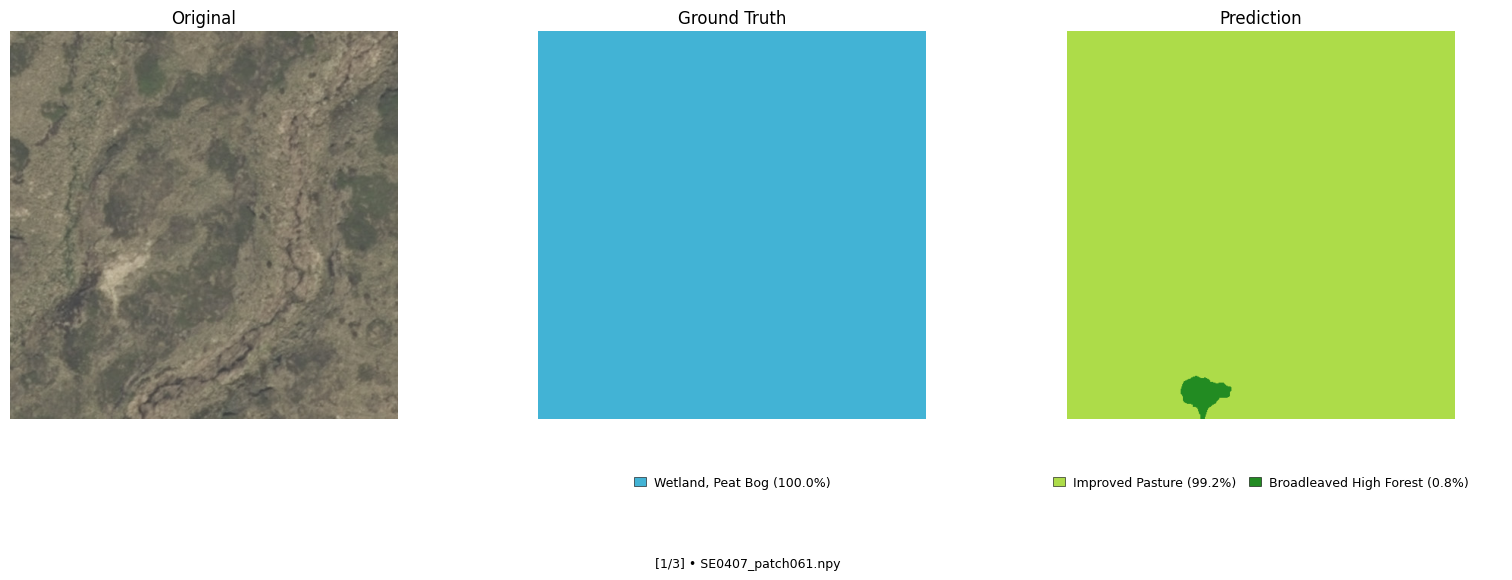

Saved: /content/predictions_fine_tuned/SE0407_patch061_fine_tuned_landscape.png


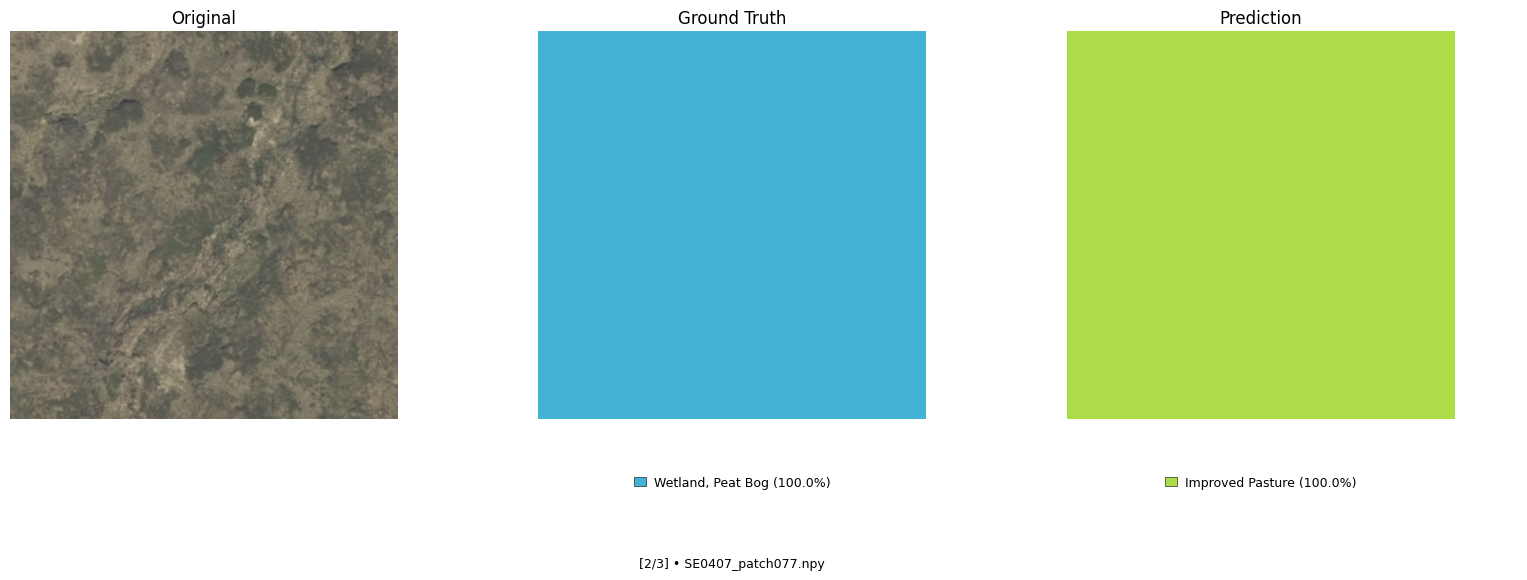

Saved: /content/predictions_fine_tuned/SE0407_patch077_fine_tuned_landscape.png


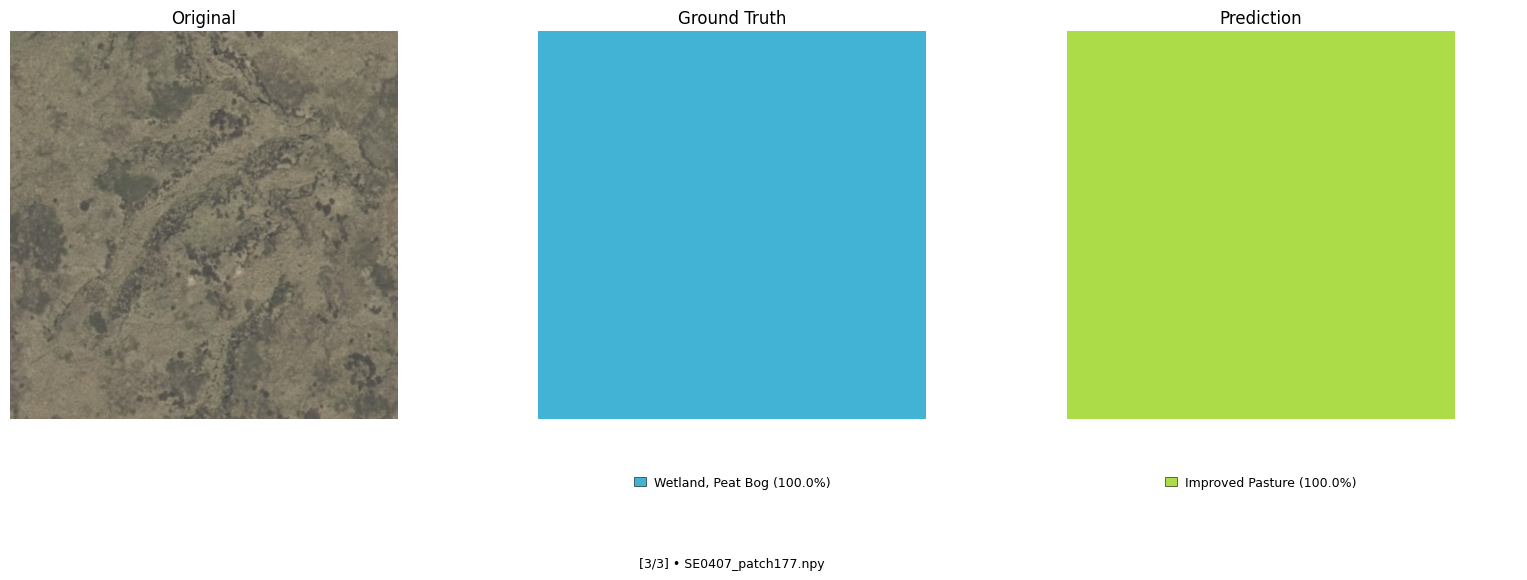

Saved: /content/predictions_fine_tuned/SE0407_patch177_fine_tuned_landscape.png
Copied fine-tuned artifacts to Drive.


In [ ]:
# === 5) FINE-TUNED: metrics + landscape triptychs with top-3 legends ===
FT_DIR = Path("/content/predictions_fine_tuned"); FT_DIR.mkdir(parents=True, exist_ok=True)

ft_model.eval(); ys, ps = [], []
with torch.no_grad():
    for x,y,_ in test_loader:
        x=x.to(DEVICE); y=y.to(DEVICE)
        out = ft_model(pixel_values=x).logits
        up  = F.interpolate(out, size=y.shape[-2:], mode="bilinear", align_corners=False)
        pred= up.argmax(dim=1).cpu().numpy().astype(np.int64)
        ys.append(y.cpu().numpy().astype(np.int64).ravel()); ps.append(pred.ravel())

if ys:
    y_true = np.concatenate(ys); y_pred = np.concatenate(ps)
    labels=np.arange(max(int(y_pred.max()),0)+1)
    cm = confusion_matrix(y_true,y_pred,labels=labels)
    pacc = float(cm.trace()/cm.sum()) if cm.sum()>0 else 0.0
    inter=np.diag(cm).astype(np.float64); union=cm.sum(axis=1)+cm.sum(axis=0)-inter
    miou = float(np.nanmean(inter/np.maximum(union,1)))
else:
    pacc, miou = 0.0, 0.0

print(f"Fine-tuned PixelAcc={pacc*100:.2f}%, mIoU={miou*100:.2f}%")
pd.DataFrame([{"pixel_acc":pacc,"miou":miou}]).to_csv("/content/segformer_b0_finetuned_metrics.csv", index=False)

def legend_in_axis(ax, items, ncol=3):
    ax.axis("off")
    handles = [mpatches.Patch(facecolor=c, edgecolor='black', linewidth=0.4) for (_,_,_,c) in items]
    labels  = [f"{n} ({p:.1f}%)" for (_,n,p,_) in items]
    if not labels:
        labels, handles = ["(no classes)"], [mpatches.Patch(facecolor=(0,0,0,0))]
    ax.legend(handles, labels, loc="center", ncol=min(ncol, max(1,len(labels))),
              frameon=False, fontsize=9, handlelength=1, handletextpad=0.6, columnspacing=1.0)

for rank, name in enumerate(sel3, start=1):
    img = load_img_chw_float01(IMG_DIR / name)
    gt  = load_mask_hw(MASK_DIR / name.replace(".npy","_lc_2022_detailed_mask.npy"))
    with torch.no_grad():
        t = torch.from_numpy(img).unsqueeze(0).to(DEVICE)
        out = ft_model(pixel_values=t).logits
        up  = F.interpolate(out, size=gt.shape[-2:], mode="bilinear", align_corners=False)
        pred= up.argmax(dim=1)[0].cpu().numpy().astype(np.int64)

    gt_rgb, pr_rgb = mask_to_rgb(gt), mask_to_rgb(pred)
    gt_items, pr_items = summarize(gt,3), summarize(pred,3)

    fig = plt.figure(figsize=(16,6))
    gs  = fig.add_gridspec(nrows=2, ncols=3, height_ratios=[4,1])
    ax_o = fig.add_subplot(gs[0,0]); ax_g = fig.add_subplot(gs[0,1]); ax_p = fig.add_subplot(gs[0,2])
    ax_gl= fig.add_subplot(gs[1,1]); ax_pl= fig.add_subplot(gs[1,2])

    orig = (np.transpose(img,(1,2,0))*255).astype(np.uint8)
    if orig.shape[2]==1: orig=np.repeat(orig,3,axis=2)
    ax_o.imshow(orig); ax_o.set_title("Original"); ax_o.axis("off")
    ax_g.imshow(gt_rgb); ax_g.set_title("Ground Truth"); ax_g.axis("off")
    ax_p.imshow(pr_rgb); ax_p.set_title("Prediction"); ax_p.axis("off")
    legend_in_axis(ax_gl, gt_items); legend_in_axis(ax_pl, pr_items)
    fig.text(0.5, 0.02, f"[{rank}/3] • {name}", ha="center", va="bottom", fontsize=9)

    outp = FT_DIR / f"{Path(name).stem}_fine_tuned_landscape.png"
    plt.tight_layout(rect=[0,0.06,1,0.98]); plt.savefig(outp, dpi=140, bbox_inches="tight"); plt.show()
    print("Saved:", outp)

if RUNS_DRIVE:
    (RUNS_DRIVE/"finetune").mkdir(parents=True, exist_ok=True)
    shutil.copy2("/content/segformer_b0_finetuned_metrics.csv", RUNS_DRIVE/"finetune/segformer_b0_finetuned_metrics.csv")
    for p in FT_DIR.glob("*.png"): shutil.copy2(p, RUNS_DRIVE/"finetune"/p.name)
    print("Copied fine-tuned artifacts to Drive.")
